# Trabajo Práctico Especial

Señales y Sistemas (TB065) - Curso 2 - Grupo 11 - 1C2025 - FIUBA  
Martin Klöckner - mklockner@fi.uba.ar  
Pablo Martinez Madero - pmartinezm@fi.uba.ar  
Ernesto Dei Castelli - edei@fi.uba.ar  

## Análisis de las Señales

**Introduccion...**

Para la realización de los gráficos se utiliza el lenguaje de programación
[python](https://www.python.org) junto con las librerías
[scipy](https://docs.scipy.org/doc/scipy/index.html),
[matplotlib](https://matplotlib.org/) y
[numpy](https://numpy.org/doc/stable/index.html).

### Obtención y Muestra de Archivos

Se importan las librerías mencionadas previamente en un script
de python, incluyendo el método [urlretrieve](https://docs.python.org/3/library/urllib.request.html#urllib.request.urlretrieve) del módulo [urllib.request](https://docs.python.org/3/library/urllib.request.html#module-urllib.request) para obtener localmente los archivos a analizar.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from scipy.io import wavfile
from urllib.request import urlretrieve

Para obtener los archivos a analizar, se define una variable para almacenar el nombre de los archivos y se descargan utilizando el método [urlretrieve](https://docs.python.org/3/library/urllib.request.html#urllib.request.urlretrieve) proporcionando las respectivas urls y el nombre final que se desea que tengan los archivos una vez descargados.

In [2]:
short_sample_file_name = 'picasso_short.wav'
long_sample_file_name = 'picasso_long.wav'

urlretrieve('https://github.com/mjkloeckner/TB065/raw/main/data/picasso_short.wav', short_sample_file_name);
urlretrieve('https://github.com/mjkloeckner/TB065/raw/main/data/picasso_long.wav', long_sample_file_name);

Continuamos leyendo el contenido del primer archivo de nombre `picasso_short.wav`, para lo cual se utiliza el método [wavfile.read](https://docs.scipy.org/doc/scipy/reference/generated/scipy.io.wavfile.read.html#read) de la librería [scipy](https://docs.scipy.org/doc/scipy/index.html). Esta función devuelve los datos y la tasa de muestreo leidos del archivo en formato WAV cuyo nombre recibe como argumento.

In [3]:
short_sample_rate, short_sample_data = wavfile.read(short_sample_file_name)

Para graficar los datos obtenidos resulta conveniente definir la función `graph_data`, la cual utiliza métodos del módulo [pyplot](https://matplotlib.org/stable/api/pyplot_summary.html#module-matplotlib.pyplot) de la librería [matplotlib](https://matplotlib.org/) para generar los gráficos pedidos. Esto además permite evitar patrones repetitivos en el código,

In [4]:
def graph_data(x, y, title, figure_number=0, t=0, dt=0, a=0, da=0):
  figure, axis = plt.subplots(num=title, figsize=(12, 6))
  figure_caption = 'Figura ' + str(figure_number) + ': ' + title
  figure.text(.5, -0.02, figure_caption, ha='center', fontsize=12)

  plt.plot(x, y, label='Señal de Audio')
  axis.set(xlabel='Tiempo [s]', ylabel='Amplitud')
  plt.grid(True)
  plt.legend()
  plt.xlim([t, t+dt if t != 0 else x[-1]])

  if a != 0: # resaltado
    axis.axvspan(a, a+da, color='skyblue', alpha=0.50)

  plt.show()

Para poder graficar los datos se necesita saber a qué tiempo corresponde cada valor de la señal; para eso, se utiliza el método [arange](https://numpy.org/doc/stable/reference/generated/numpy.arange.html#numpy-arange) de la libreria [numpy](https://numpy.org/doc/stable/index.html). Este método devuelve un arreglo de números equidistantes del largo que recibe como parámetro, en este caso del largo de los datos leídos del archivo. Para convertirlo a segundos se divide por la tasa de muestreo, la cual también se obtiene cuando se lee el archivo.

In [5]:
short_sample_time = np.arange(len(short_sample_data)) / short_sample_rate

Se define una variable para almacenar el título de la figura, esto para posteriormente pasarlo como argumento a la función `graph_data`.

In [6]:
title = 'Gráfico de `' + str(short_sample_file_name) + '` en dominio de tiempo'

Finalmente se grafica el pimer archivo utilizando la funcion `graph_data`

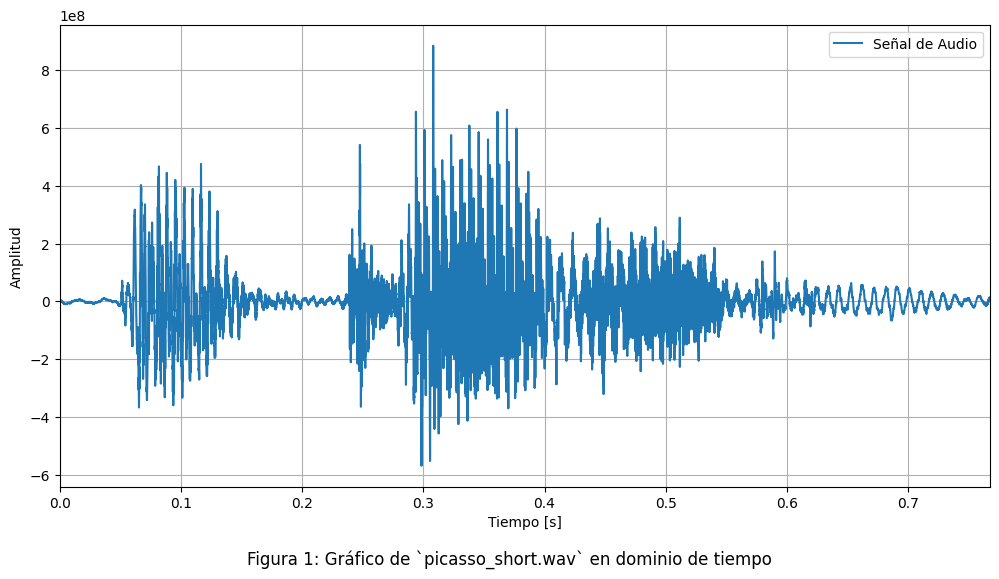

In [7]:
graph_data(short_sample_time, short_sample_data, title, 1)

Ahora realizamos exactamente el mismo procedimiento para el segundo archivo de aproximadamente el doble de duración.

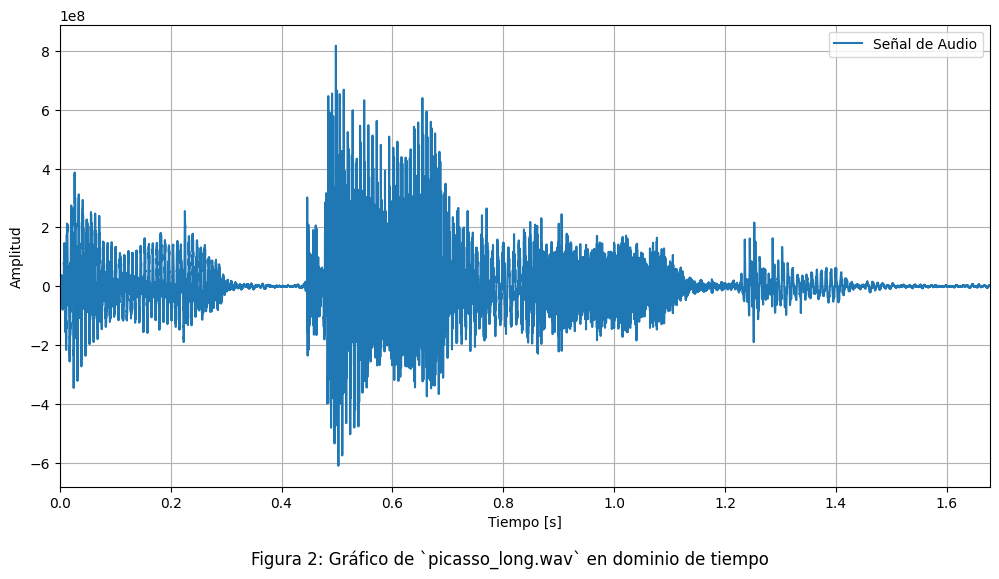

In [8]:
long_sample_rate, long_sample_data = wavfile.read(long_sample_file_name)
long_sample_time = np.arange(len(long_sample_data)) / long_sample_rate
title = 'Gráfico de `' + str(long_sample_file_name) + '` en dominio de tiempo'
graph_data(long_sample_time, long_sample_data, title, 2)

### Ejemplo de Señales Periodicas

Haciendo una inspeccion visual de las señales graficadas en las figuras 1 y 2, se identifican ciertas partes que tienen un patron que se repite despues de un intervalo de tiempo.

#### Archivo corto

Para el primer archivo, se toma como ejemplo el intervalo entre `0.08` y `0.12` en los cuales se observa un periódo que parece repetirse cada `0.0093s`, esto resulta en una frecuencia de aproximadamente `107.5Hz`; dicho intervalo de la señal se puede ver en figura 3, en la cual también se resalta el período fundamental de la misma.

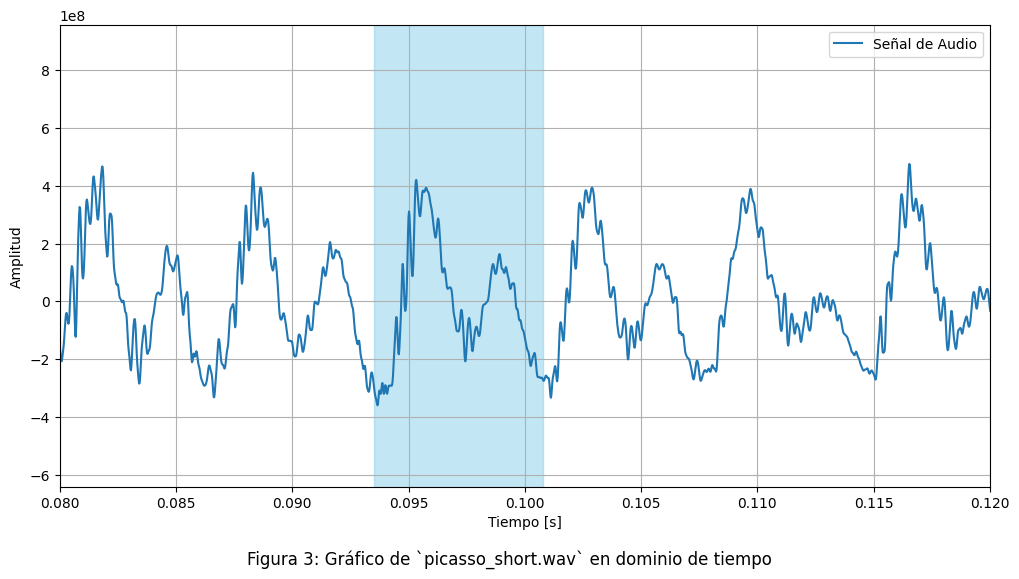

In [9]:
title = 'Gráfico de `' + str(short_sample_file_name) + '` en dominio de tiempo'
graph_data(short_sample_time, short_sample_data, title, 3, t=0.08, dt=0.04, a=0.0935, da=0.0073)

#### Archivo largo

De manera analoga que para el primer archivo se realiza una inspección visual de la señal, en este caso se toma el intervalo entre `0.08s` y `0.120s` como se observa en la figura 4, además en la misma se grafica el periodo fundamental el cual resulta aproximadamente `0.00756s`, resultando en una frecuencia aproximada de `132.3Hz`

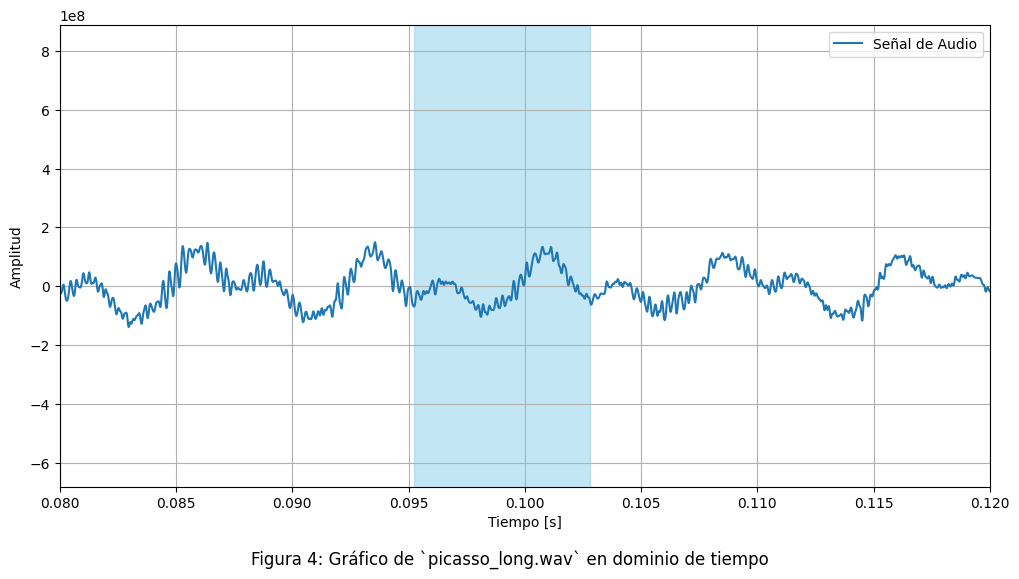

In [10]:
title = 'Gráfico de `' + str(long_sample_file_name) + '` en dominio de tiempo'
graph_data(long_sample_time, long_sample_data, title, 4, t=0.08, dt=0.04, a=0.09525, da=0.00756)

### Ejemplo de Señales no Periodicas

Similar a lo realizado para las señales en busca de intervalos peridicos, se realiza una inspeccion visual de la señal, pero esta vez buscando patrones no repetitivos.

#### Archivo corto

A continuacion se muestra un intervalo de la señal en donde no es períodica, se puede ver que si bien parece haber un patron repetitivo y asemejar a una señal senoidal, no se puede considerar períodica porque la señal montada o ruido no es periodico, por lo que la señal resultante no lo es.

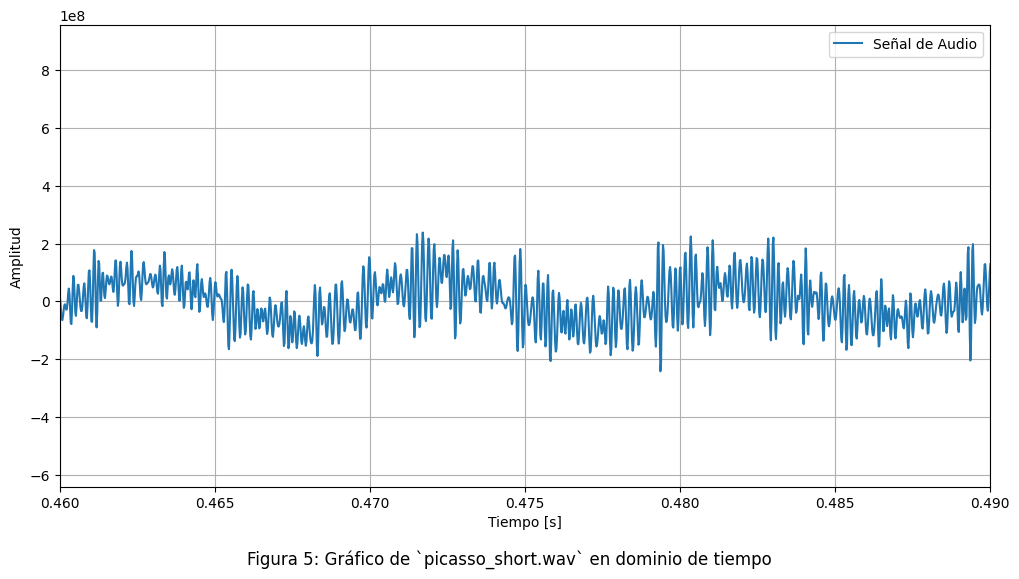

In [11]:
title = 'Gráfico de `' + str(short_sample_file_name) + '` en dominio de tiempo'
graph_data(short_sample_time, short_sample_data, title, 5, t=0.46, dt=0.03);

#### Archivo largo

Para el archivo largo se toma el intervalo entre `0.445s` y `0.460` como ejemplo de intervalo no periodico de la señal, este intervalo se puede ver en la figura XX

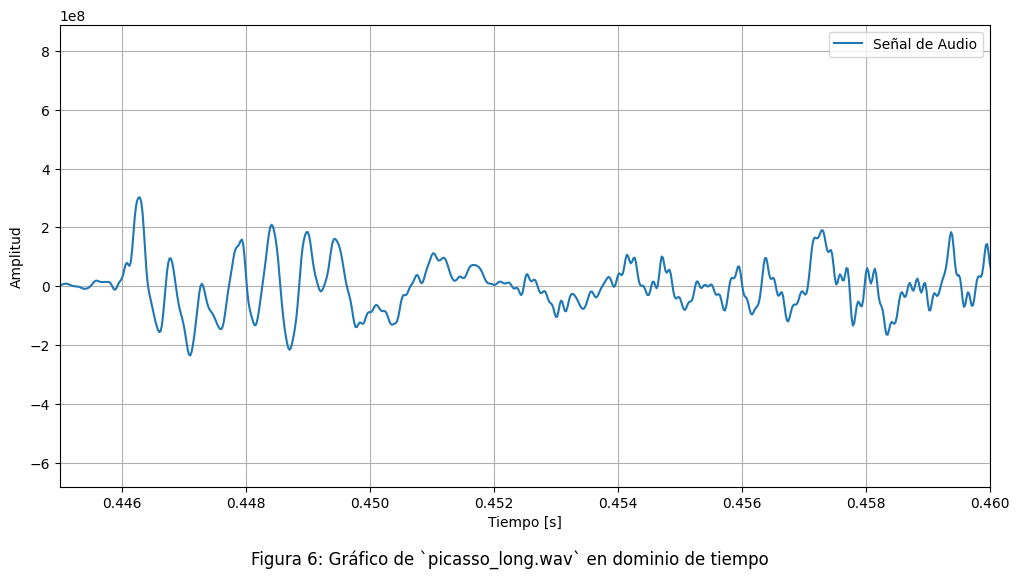

In [12]:
title = 'Gráfico de `' + str(long_sample_file_name) + '` en dominio de tiempo'
graph_data(long_sample_time, long_sample_data, title, 6, t=0.445, dt=0.015)

### Identificación de las sonidos vocalicos

En la figura 7 el grafico resaltado corresponde con el sonido vocalico `[a]` ya que se asemeja a un tren de impulsos cuasi-periodico.

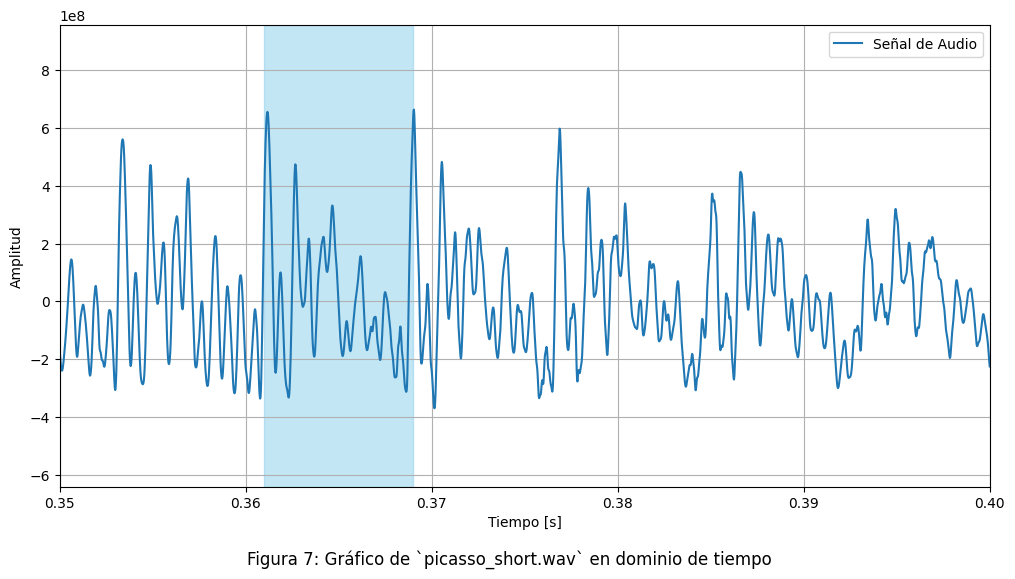

In [13]:
title = 'Gráfico de `' + str(short_sample_file_name) + '` en dominio de tiempo'
graph_data(short_sample_time, short_sample_data, title, 7, t=0.35, dt=0.05, a=0.361, da=0.008);

El sonido vocalico `[s]` corresponde con una señal de entrada del sistema de ruido blanco, este patron se identifica en la figura 6, en la cual se puede ver una señal senoidal la cual parece tener montada una señal de ruido blanco.

## Calculos de los coeficientes de la Serie de Fourier

Para graficar los coeficientes de Fourier, se utiliza

In [14]:
from scipy.fft import fft, fftfreq
from matplotlib.ticker import MultipleLocator

def graph_fft(signal, sample_rate, t, dt, title, figure_number, tick, f_max):
  i = int(t*sample_rate)
  di = int((t+dt)*sample_rate)

  interval_data = signal[i:di]
  interval_fft = fft(interval_data)
  interval_freqs = fftfreq(len(interval_data), d=1/sample_rate)

  # Se toma la parte positiva en ambos casos (primer parte del arreglo).
  x = interval_freqs[:len(interval_data) // 2]
  y = np.abs(interval_fft[:len(interval_data) // 2])

  figure, axis = plt.subplots(num=title, figsize=(12, 6))
  figure_caption = 'Figura ' + str(figure_number) + ': ' + title
  figure.text(.5, -0.02, figure_caption, ha='center', fontsize=12)
  plt.plot(x, y)
  plt.grid()
  plt.gca().xaxis.set_major_locator(MultipleLocator(tick))
  axis.set(xlabel='Frecuencia [Hz]', ylabel='Amplitud')
  plt.xlim(0,f_max)
  plt.show()

### Utilizando un solo periodo

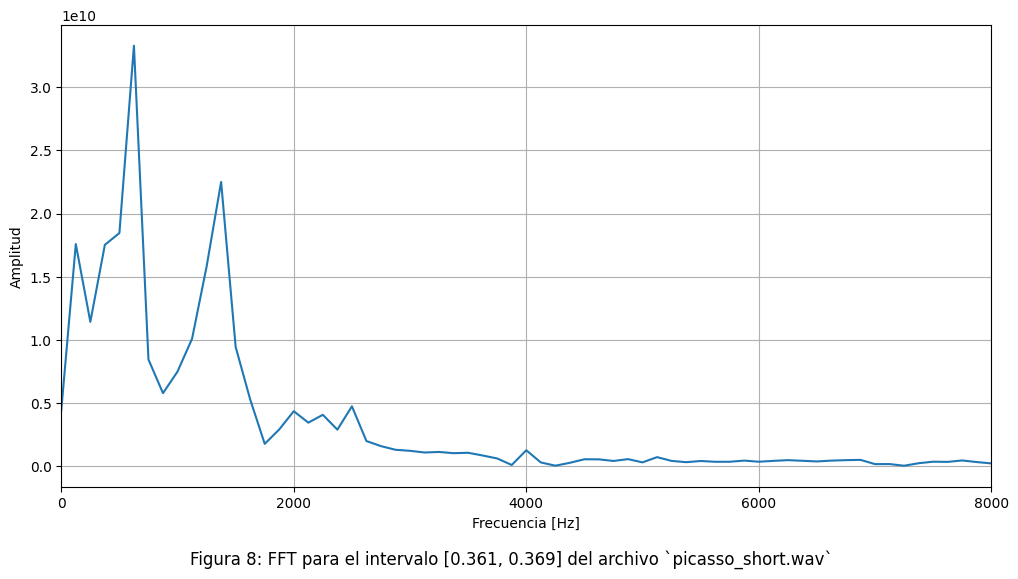

In [15]:
t=0.361
dt=0.008 # 0.361 + 0.008 = 0.369
title = f'FFT para el intervalo [{t}, {t+dt}] del archivo `{short_sample_file_name}`'
graph_fft(short_sample_data, short_sample_rate, t, dt, title, 8, 2000, 8000)

Tomando 4 periodos de la señal, la transformada de Fourier resulta como se ve en la figura 9 a continuación, se puede ver que tiene mucho mas "detalle" que la figura 7, en la cual se tomaba solo un periodo para realizar la FFT

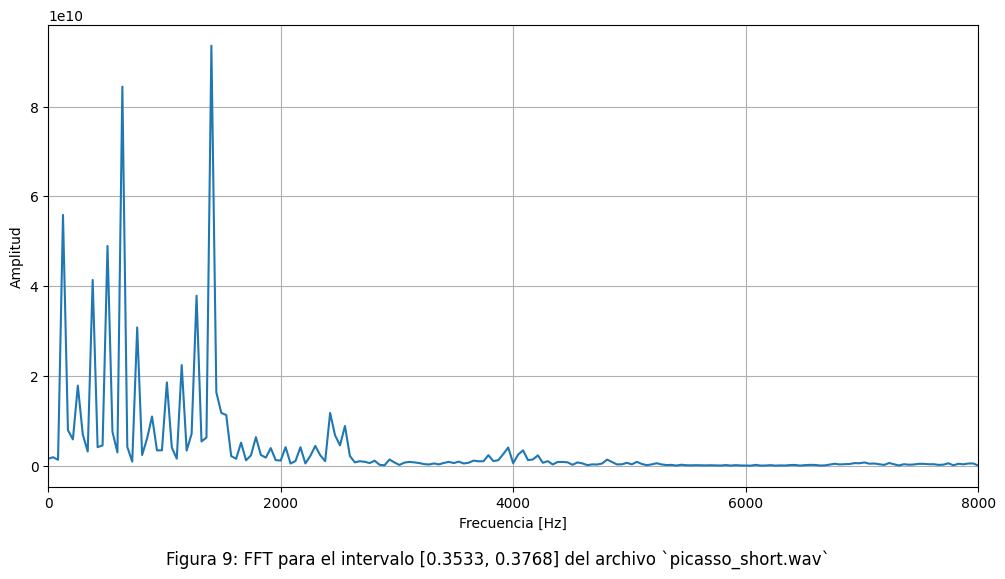

In [16]:
t=0.3533
dt=0.0235
title = f'FFT para el intervalo [{t}, {t+dt}] del archivo `{short_sample_file_name}`'
graph_fft(short_sample_data, short_sample_rate, t, dt, title, 9, 2000, 8000)